# Lund-plane tagging sensitivity with the data repository

This notebook repeats the toy sensitivity workflow using the JSON jet samples from the `JetsGame/data` repository. It compares

- `W` jets vs `QCD` jets,
- `top` jets vs `QCD` jets,

by reclustering each jet, converting it to primary Lund-plane histograms, and fitting a simple linear classifier. The classifier coefficients are not meant to be a final tagger. They are a readable diagnostic for which Lund-plane regions carry discrimination.

## Data setup

The default paths assume the data repository is checked out next to this repository:

```text
lundnet-repo/
  LundNet/
  data/
```

The data repo is Git LFS based. If the files are only LFS pointer files, run this in a terminal before executing the notebook:

```bash
git -C ../data lfs pull
```

Start with a small `N_JETS` while iterating; reclustering tens of thousands of jets takes time.

In [16]:
from pathlib import Path
import gzip
import sys

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Make local src imports work when the notebook is launched from studies/.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "studies":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from lundnet.read_data import Jets
from lundnet.JetTree import JetTree

plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": False})

In [ ]:
DATA_ROOT = (REPO_ROOT / ".." / "data").resolve()
SPLIT = "test"
ENERGY = "500GeV"

# Use "" for truth-level files, or choose variants such as "_hadron", "_parton", "_delphes" when present.
LEVEL_SUFFIX = ""

# Increase after checking the workflow. The full test files contain many more jets.
N_JETS = 200000

DATA_FILES = {
    "qcd": DATA_ROOT / SPLIT / f"{SPLIT}_QCD_{ENERGY}{LEVEL_SUFFIX}.json.gz",
    "w": DATA_ROOT / SPLIT / f"{SPLIT}_WW_{ENERGY}{LEVEL_SUFFIX}.json.gz",
    "top": DATA_ROOT / SPLIT / f"{SPLIT}_Top_{ENERGY}{LEVEL_SUFFIX}.json.gz",
}

for label, path in DATA_FILES.items():
    print(f"{label:>3}: {path}")

qcd: /mnt/nvme0n1p4/HEP/Work/phenomenology/lundnet-study/lundnet-repo/data/test/test_QCD_500GeV.json.gz
  w: /mnt/nvme0n1p4/HEP/Work/phenomenology/lundnet-study/lundnet-repo/data/test/test_WW_500GeV.json.gz
top: /mnt/nvme0n1p4/HEP/Work/phenomenology/lundnet-study/lundnet-repo/data/test/test_Top_500GeV.json.gz


In [18]:
def is_lfs_pointer(path):
    if not path.exists():
        return False
    with open(path, "rb") as f:
        return f.read(64).startswith(b"version https://git-lfs.github.com/spec")


def validate_data_files(paths):
    missing = [str(p) for p in paths.values() if not p.exists()]
    pointers = [str(p) for p in paths.values() if is_lfs_pointer(p)]
    if missing or pointers:
        msg = []
        if missing:
            msg.append("Missing files:\n" + "\n".join(missing))
        if pointers:
            msg.append("Git LFS pointer files, not real gzip data:\n" + "\n".join(pointers))
        msg.append("\nFetch the real data with: git -C ../data lfs pull")
        raise RuntimeError("\n\n".join(msg))
    for path in paths.values():
        with gzip.open(path, "rb") as f:
            f.read(1)


validate_data_files(DATA_FILES)
print("Data files are present and readable.")

Data files are present and readable.


## Build primary Lund-plane histograms

For each jet, we recluster with the existing LundNet reader, build a `JetTree`, and fill a histogram in

- $x = -\ln\Delta = \ln(1/\Delta)$,
- $y = \ln k_t$.

By default, only the primary Lund plane is used: after each declustering, the recursion follows the harder branch. Set `PRIMARY_ONLY = False` to include secondary branches too.

In [19]:
X_RANGE = (0.0, 7.0)
Y_RANGE = (-3.0, 7.0)
NX = 40
NY = 40
XBINS = np.linspace(*X_RANGE, NX + 1)
YBINS = np.linspace(*Y_RANGE, NY + 1)
PRIMARY_ONLY = True


def collect_lund_points(tree, primary_only=True):
    points = []

    def visit(node):
        if node is None or node.lundCoord is None:
            return
        points.append((-float(node.lundCoord.lnDelta), float(node.lundCoord.lnKt)))
        visit(node.harder)
        if not primary_only:
            visit(node.softer)

    visit(tree)
    return np.asarray(points, dtype=float)


def histogram_points(points):
    if len(points) == 0:
        return np.zeros((NX, NY), dtype=np.float32)
    hist, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=[XBINS, YBINS])
    return hist.astype(np.float32)


def load_lund_histograms(path, n_jets, primary_only=True):
    hists = []
    point_clouds = []
    for jet in Jets(str(path), n_jets):
        tree = JetTree(jet)
        points = collect_lund_points(tree, primary_only=primary_only)
        point_clouds.append(points)
        hists.append(histogram_points(points))
    return np.stack(hists), point_clouds

In [20]:
H_qcd, points_qcd = load_lund_histograms(DATA_FILES["qcd"], N_JETS, PRIMARY_ONLY)
H_w, points_w = load_lund_histograms(DATA_FILES["w"], N_JETS, PRIMARY_ONLY)
H_top, points_top = load_lund_histograms(DATA_FILES["top"], N_JETS, PRIMARY_ONLY)

print("QCD histograms:", H_qcd.shape)
print("W histograms:  ", H_w.shape)
print("top histograms:", H_top.shape)

# Exiting after having read nmax jet declusterings
# Exiting after having read nmax jet declusterings
# Exiting after having read nmax jet declusterings
QCD histograms: (50000, 40, 40)
W histograms:   (50000, 40, 40)
top histograms: (50000, 40, 40)


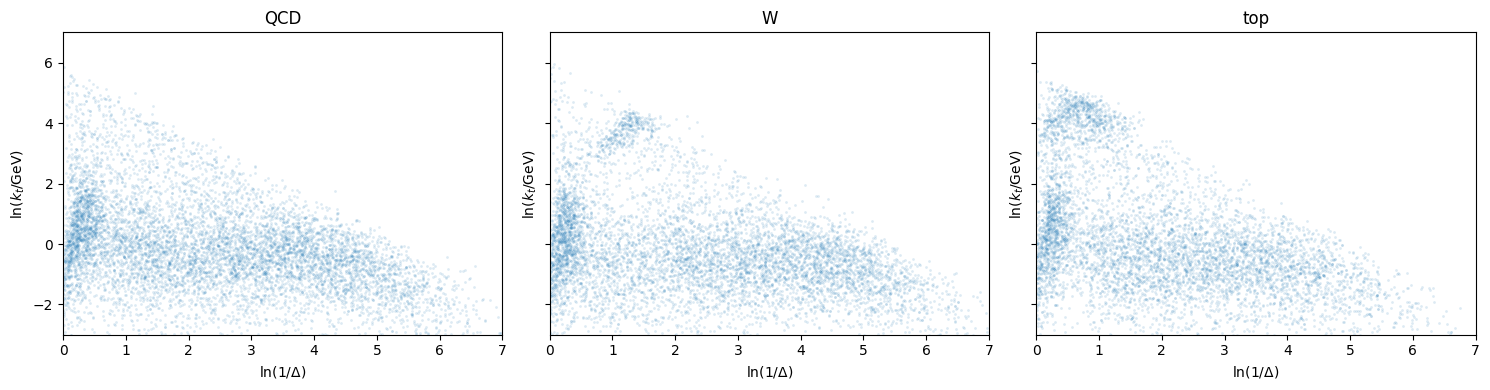

In [21]:
def plot_points(point_clouds, title, ax, max_jets=500):
    points = [p for p in point_clouds[:max_jets] if len(p)]
    if points:
        points = np.vstack(points)
        ax.scatter(points[:, 0], points[:, 1], s=4, alpha=0.15, linewidths=0)
    ax.set_title(title)
    ax.set_xlim(X_RANGE)
    ax.set_ylim(Y_RANGE)
    ax.set_xlabel(r"$\ln(1/\Delta)$")
    ax.set_ylabel(r"$\ln(k_t / \mathrm{GeV})$")


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
plot_points(points_qcd, "QCD", axes[0])
plot_points(points_w, "W", axes[1])
plot_points(points_top, "top", axes[2])
fig.tight_layout()

## Fit simple linear taggers

The inputs are log-compressed bin counts, `log1p(histogram)`. The coefficient maps highlight bins that make the linear model more signal-like or more QCD-like.

In [22]:
def fit_linear_tagger(signal_hists, background_hists, c=0.25):
    n = min(len(signal_hists), len(background_hists))
    X = np.concatenate([background_hists[:n], signal_hists[:n]]).reshape(2 * n, -1)
    y = np.concatenate([np.zeros(n), np.ones(n)])
    X = np.log1p(X)

    clf = LogisticRegression(max_iter=2000, C=c, solver="lbfgs")
    clf.fit(X, y)
    scores = clf.decision_function(X)
    auc = roc_auc_score(y, scores)
    coef = clf.coef_[0].reshape(NX, NY)
    return clf, coef, auc


w_clf, w_coef, w_auc = fit_linear_tagger(H_w, H_qcd)
top_clf, top_coef, top_auc = fit_linear_tagger(H_top, H_qcd)

print(f"W vs QCD AUC:   {w_auc:.4f}")
print(f"top vs QCD AUC: {top_auc:.4f}")

W vs QCD AUC:   0.8601
top vs QCD AUC: 0.9366


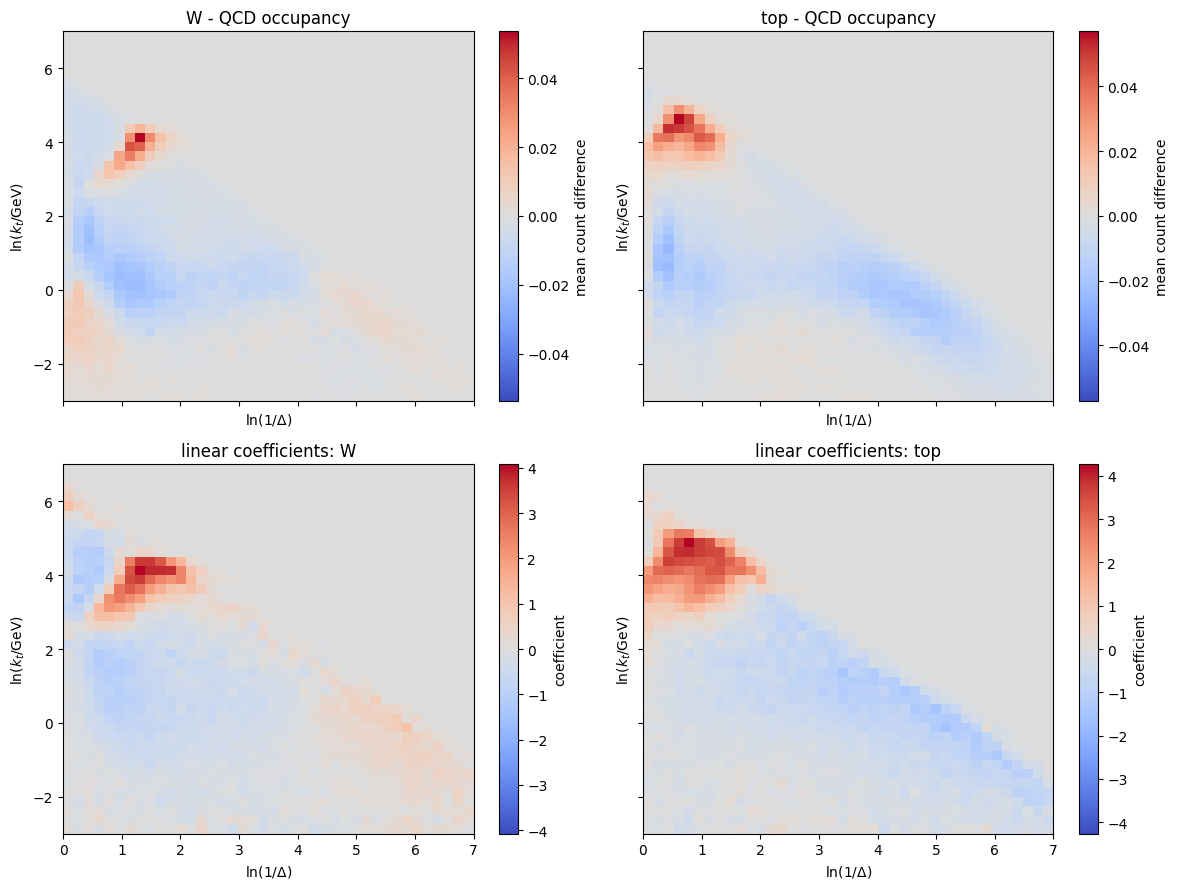

In [23]:
def plot_map(values, title, ax, cmap="coolwarm", symmetric=True):
    if symmetric:
        vmax = np.nanmax(np.abs(values))
        vmin = -vmax
    else:
        vmin, vmax = None, None
    mesh = ax.pcolormesh(XBINS, YBINS, values.T, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(r"$\ln(1/\Delta)$")
    ax.set_ylabel(r"$\ln(k_t / \mathrm{GeV})$")
    return mesh


w_delta = H_w.mean(axis=0) - H_qcd.mean(axis=0)
top_delta = H_top.mean(axis=0) - H_qcd.mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
m = plot_map(w_delta, "W - QCD occupancy", axes[0, 0])
fig.colorbar(m, ax=axes[0, 0], label="mean count difference")
m = plot_map(top_delta, "top - QCD occupancy", axes[0, 1])
fig.colorbar(m, ax=axes[0, 1], label="mean count difference")
m = plot_map(w_coef, "linear coefficients: W", axes[1, 0])
fig.colorbar(m, ax=axes[1, 0], label="coefficient")
m = plot_map(top_coef, "linear coefficients: top", axes[1, 1])
fig.colorbar(m, ax=axes[1, 1], label="coefficient")
fig.tight_layout()

## Rank sensitive regions

Positive coefficients are signal-like bins. Negative coefficients are QCD-like bins. The tables give the largest positive bins for each tagger.

In [24]:
def top_bins(coef, n=12):
    flat = coef.ravel()
    order = np.argsort(flat)[::-1][:n]
    rows = []
    for idx in order:
        ix, iy = np.unravel_index(idx, coef.shape)
        rows.append((
            0.5 * (XBINS[ix] + XBINS[ix + 1]),
            0.5 * (YBINS[iy] + YBINS[iy + 1]),
            flat[idx],
        ))
    return rows


def print_bins(title, rows):
    print(title)
    print("rank   ln(1/Delta)   ln(kT/GeV)   coefficient")
    for i, (x, y, coef) in enumerate(rows, start=1):
        print(f"{i:>4}   {x:>11.2f}   {y:>10.2f}   {coef:>11.3f}")
    print()


print_bins("Most W-sensitive bins", top_bins(w_coef))
print_bins("Most top-sensitive bins", top_bins(top_coef))

Most W-sensitive bins
rank   ln(1/Delta)   ln(kT/GeV)   coefficient
   1          1.31         4.12         4.077
   2          1.49         4.12         3.813
   3          1.66         4.12         3.783
   4          1.84         4.12         3.703
   5          1.49         4.38         3.615
   6          1.31         4.38         3.569
   7          1.31         3.88         3.559
   8          1.14         3.88         3.400
   9          1.14         4.12         3.223
  10          1.66         4.38         3.161
  11          1.14         3.62         3.111
  12          1.49         3.88         2.861

Most top-sensitive bins
rank   ln(1/Delta)   ln(kT/GeV)   coefficient
   1          0.79         4.88         4.265
   2          0.79         4.62         3.938
   3          0.61         4.62         3.884
   4          0.96         4.88         3.735
   5          0.61         4.88         3.725
   6          0.96         4.62         3.706
   7          0.44         4.38  

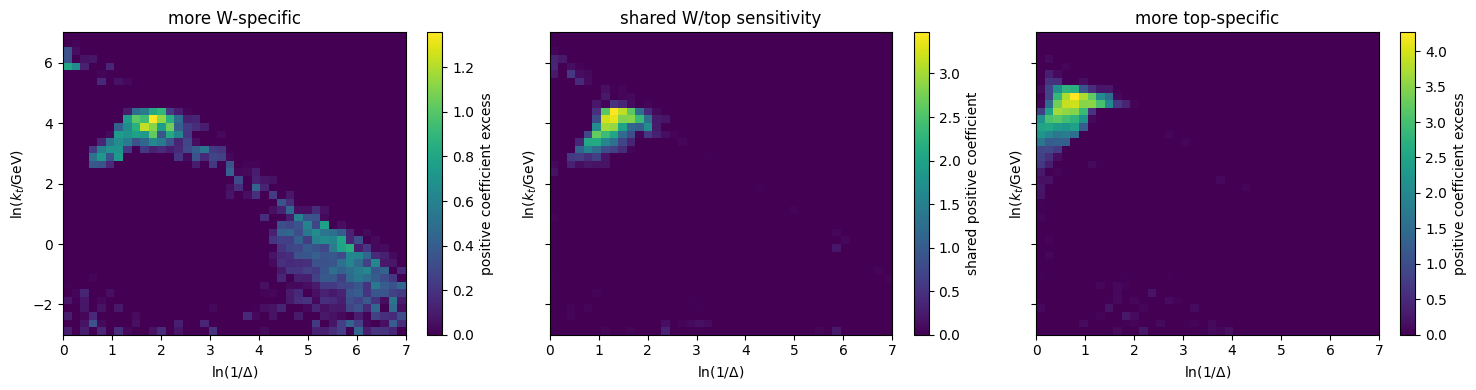

In [25]:
w_pos = np.maximum(w_coef, 0)
top_pos = np.maximum(top_coef, 0)
shared = np.minimum(w_pos, top_pos)
w_unique = w_pos - shared
top_unique = top_pos - shared

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
m = plot_map(w_unique, "more W-specific", axes[0], cmap="viridis", symmetric=False)
fig.colorbar(m, ax=axes[0], label="positive coefficient excess")
m = plot_map(shared, "shared W/top sensitivity", axes[1], cmap="viridis", symmetric=False)
fig.colorbar(m, ax=axes[1], label="shared positive coefficient")
m = plot_map(top_unique, "more top-specific", axes[2], cmap="viridis", symmetric=False)
fig.colorbar(m, ax=axes[2], label="positive coefficient excess")
fig.tight_layout()

## Region ablation check

The coefficient maps are readable, but an ablation check is often more robust. Here we keep only one coarse Lund-plane region at a time and measure its standalone AUC.

In [26]:
COARSE_X = np.array([0.0, 1.0, 2.0, 3.5, 7.0])
COARSE_Y = np.array([-3.0, 0.0, 2.0, 4.0, 7.0])


def coarse_region_scores(signal_hists, background_hists):
    rows = []
    for ix in range(len(COARSE_X) - 1):
        xmask = (XBINS[:-1] >= COARSE_X[ix]) & (XBINS[1:] <= COARSE_X[ix + 1])
        for iy in range(len(COARSE_Y) - 1):
            ymask = (YBINS[:-1] >= COARSE_Y[iy]) & (YBINS[1:] <= COARSE_Y[iy + 1])
            if not xmask.any() or not ymask.any():
                continue
            sig = signal_hists[:, xmask][:, :, ymask].sum(axis=(1, 2))
            bkg = background_hists[:, xmask][:, :, ymask].sum(axis=(1, 2))
            y = np.concatenate([np.zeros(len(bkg)), np.ones(len(sig))])
            score = np.concatenate([bkg, sig])
            auc = roc_auc_score(y, score)
            rows.append((COARSE_X[ix], COARSE_X[ix + 1], COARSE_Y[iy], COARSE_Y[iy + 1], max(auc, 1 - auc)))
    return sorted(rows, key=lambda r: r[-1], reverse=True)


def print_region_scores(title, rows, n=8):
    print(title)
    print("rank   x range          y range          standalone AUC")
    for i, (x0, x1, y0, y1, auc) in enumerate(rows[:n], start=1):
        print(f"{i:>4}   [{x0:>3.1f}, {x1:>3.1f}]   [{y0:>4.1f}, {y1:>3.1f}]        {auc:.3f}")
    print()


print_region_scores("Best single regions for W vs QCD", coarse_region_scores(H_w, H_qcd))
print_region_scores("Best single regions for top vs QCD", coarse_region_scores(H_top, H_qcd))

Best single regions for W vs QCD
rank   x range          y range          standalone AUC
   1   [1.0, 2.0]   [ 0.0, 2.0]        0.649
   2   [0.0, 1.0]   [ 0.0, 2.0]        0.599
   3   [2.0, 3.5]   [ 0.0, 2.0]        0.595
   4   [1.0, 2.0]   [ 4.0, 7.0]        0.589
   5   [1.0, 2.0]   [-3.0, 0.0]        0.579
   6   [0.0, 1.0]   [-3.0, 0.0]        0.565
   7   [1.0, 2.0]   [ 2.0, 4.0]        0.560
   8   [0.0, 1.0]   [ 4.0, 7.0]        0.557

Best single regions for top vs QCD
rank   x range          y range          standalone AUC
   1   [0.0, 1.0]   [ 4.0, 7.0]        0.727
   2   [3.5, 7.0]   [-3.0, 0.0]        0.709
   3   [3.5, 7.0]   [ 0.0, 2.0]        0.674
   4   [2.0, 3.5]   [ 0.0, 2.0]        0.611
   5   [0.0, 1.0]   [ 0.0, 2.0]        0.610
   6   [1.0, 2.0]   [ 0.0, 2.0]        0.587
   7   [0.0, 1.0]   [ 2.0, 4.0]        0.576
   8   [1.0, 2.0]   [ 4.0, 7.0]        0.563



## Reading the maps

A robust interpretation should compare three views:

- occupancy maps: where the signal has more or fewer declusterings than QCD;
- linear coefficient maps: where a simple multivariate tagger places positive or negative weight;
- coarse ablation scores: whether a large Lund-plane phase-space region has standalone discrimination.

W-sensitive regions are expected to trace the two-prong electroweak decay scale. Top-sensitive regions should include W-like substructure plus additional phase space from the top decay, often at wider angles and/or higher $k_t$ than the W-only tagger. The exact locations depend on the chosen energy, hadron/parton/delphes level, primary-vs-full Lund plane choice, and grooming/cuts.